<a href="https://colab.research.google.com/github/samreenfathima18/Guvi-Final-project/blob/main/LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Data Preparation**

In [ ]:
!pip install -q tensorflow pyarrow

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import joblib
import warnings
import os

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")

print(tf.__version__)

2.20.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_PATH="/content/drive/MyDrive/Enterprise_Retail_Intelligence/outputs/"

df=pd.read_parquet(
    DATA_PATH+"feature_engineered_CA1.parquet"
)

print(df.shape)

(5832737, 43)


In [ ]:
df=df.sort_values(
    ["store_id","item_id","date"]
).reset_index(drop=True)

In [ ]:
cat_cols=[

"item_id",

"dept_id",

"cat_id",

"store_id",

"state_id",

"weekday"

]

encoders={}

for col in cat_cols:

    le=LabelEncoder()

    df[col]=le.fit_transform(df[col].astype(str))

    encoders[col]=le

In [ ]:
FEATURES=[

'item_id',

'dept_id',

'cat_id',

'store_id',

'state_id',

'wm_yr_wk',

'weekday',

'wday',

'month',

'year',

'snap_CA',

'snap_TX',

'snap_WI',

'sell_price',

'day',

'week',

'quarter',

'is_weekend',

'is_month_start',

'is_month_end',

'lag_1',

'lag_7',

'lag_14',

'lag_28',

'rolling_mean_7',

'rolling_std_7',

'rolling_mean_14',

'rolling_std_14',

'rolling_mean_28',

'rolling_std_28',

'price_change',

'price_diff',

'price_rolling_mean',

'is_event',

'is_snap'

]

TARGET="sales"

In [ ]:
scaler=MinMaxScaler()

df[FEATURES]=scaler.fit_transform(df[FEATURES])

In [ ]:
float_cols=df.select_dtypes(include=["float64"]).columns

df[float_cols]=df[float_cols].astype("float32")

int_cols=df.select_dtypes(include=["int64"]).columns

df[int_cols]=df[int_cols].astype("int32")

**SKU-wise Sequence Generator**

**Sequence Parameters**

In [ ]:
LOOKBACK = 28
BATCH_SIZE = 256

**Split Data Before Sequence Generation**

In [ ]:
# Sort once more for safety
df = df.sort_values(["store_id", "item_id", "date"]).reset_index(drop=True)

# Time-based split
train_end = int(len(df) * 0.70)
valid_end = int(len(df) * 0.85)

train_df = df.iloc[:train_end].copy()
valid_df = df.iloc[train_end:valid_end].copy()
test_df = df.iloc[valid_end:].copy()

print(train_df.shape)
print(valid_df.shape)
print(test_df.shape)

(4082915, 43)
(874911, 43)
(874911, 43)


**Sequence Generator**

In [ ]:
def sequence_generator(dataframe, features, target, lookback):

    grouped = dataframe.groupby(["store_id", "item_id"])

    for (_, _), group in grouped:

        group = group.sort_values("date")

        if len(group) <= lookback:
            continue

        X = group[features].values.astype(np.float32)
        y = group[target].values.astype(np.float32)

        for i in range(lookback, len(group)):
            yield (
                X[i-lookback:i],
                y[i]
            )

**Define Output Signature**

In [ ]:
output_signature = (

    tf.TensorSpec(
        shape=(LOOKBACK, len(FEATURES)),
        dtype=tf.float32
    ),

    tf.TensorSpec(
        shape=(),
        dtype=tf.float32
    )

)

**Create TensorFlow Datasets**

In [ ]:
train_ds = tf.data.Dataset.from_generator(

    lambda: sequence_generator(
        train_df,
        FEATURES,
        TARGET,
        LOOKBACK
    ),

    output_signature=output_signature

)

valid_ds = tf.data.Dataset.from_generator(

    lambda: sequence_generator(
        valid_df,
        FEATURES,
        TARGET,
        LOOKBACK
    ),

    output_signature=output_signature

)

test_ds = tf.data.Dataset.from_generator(

    lambda: sequence_generator(
        test_df,
        FEATURES,
        TARGET,
        LOOKBACK
    ),

    output_signature=output_signature
)

**Batch and Prefetch**

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    train_ds
    .shuffle(5000)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

valid_ds = (
    valid_ds
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

**Verify Dataset**

In [ ]:
for X_batch, y_batch in train_ds.take(1):

    print("Input Shape :", X_batch.shape)
    print("Target Shape:", y_batch.shape)

Input Shape : (256, 28, 35)
Target Shape: (256,)


**Enterprise Bidirectional LSTM**

**Import Libraries**

In [ ]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    Bidirectional,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

**Build Enterprise LSTM**

In [ ]:
model = Sequential([

    Bidirectional(
        LSTM(
            64,
            return_sequences=True
        ),
        input_shape=(LOOKBACK, len(FEATURES))
    ),

    BatchNormalization(),

    Dropout(0.30),

    LSTM(
        32,
        return_sequences=False
    ),

    BatchNormalization(),

    Dropout(0.30),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.20),

    Dense(1)

])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 28, 128)        │        51,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73,537 (287.25 KB)

 Trainable params: 73,217 (286.00 KB)

 Non-trainable params: 320 (1.25 KB)

**Compile Model**

In [ ]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="mse",

    metrics=[
        "mae"
    ]

)

**Callbacks**

In [ ]:
MODEL_PATH = "/content/drive/MyDrive/Enterprise_Retail_Intelligence/models/"

os.makedirs(MODEL_PATH, exist_ok=True)

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=3,

    verbose=1,

    min_lr=1e-6

)

checkpoint = ModelCheckpoint(

    filepath=MODEL_PATH + "best_enterprise_lstm.keras",

    monitor="val_loss",

    save_best_only=True,

    verbose=1
)

**Train Model**

In [ ]:
history = model.fit(

    train_ds,



    validation_data=valid_ds,

    epochs=25,

    callbacks=[

        early_stop,

        reduce_lr,

        checkpoint

    ],

    verbose=1
)

Epoch 1/25
  15716/Unknown 3653s 232ms/step - loss: 9.9153 - mae: 1.4202
Epoch 1: val_loss improved from None to 3.10219, saving model to /content/drive/MyDrive/Enterprise_Retail_Intelligence/models/best_enterprise_lstm.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Enterprise_Retail_Intelligence/models/best_enterprise_lstm.keras
15716/15716 ━━━━━━━━━━━━━━━━━━━━ 4070s 258ms/step - loss: 5.9135 - mae: 1.0371 - val_loss: 3.1022 - val_mae: 0.9150 - learning_rate: 0.0010
Epoch 2/25
15716/15716 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - loss: 8.7029 - mae: 1.3098
Epoch 2: val_loss improved from 3.10219 to 2.98129, saving model to /content/drive/MyDrive/Enterprise_Retail_Intelligence/models/best_enterprise_lstm.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Enterprise_Retail_Intelligence/models/best_enterprise_lstm.keras
15716/15716 ━━━━━━━━━━━━━━━━━━━━ 4055s 258ms/step - loss: 5.3969 - mae: 0.9882 - val_loss: 2.9813 - val_mae: 0.8460 - learning_rate: 0.0010
Epoch

**Plot Training History**

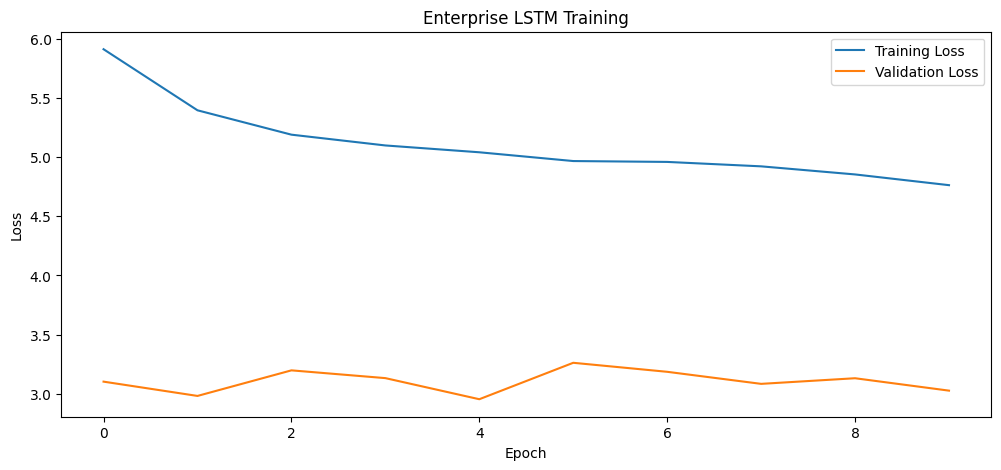

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Enterprise LSTM Training")

plt.legend()

plt.show()

**Evaluation**

**Predict**

In [ ]:
y_true = []
y_pred = []

for X_batch, y_batch in test_ds:

    pred = model.predict(
        X_batch,
        verbose=0
    )

    y_true.extend(
        y_batch.numpy()
    )

    y_pred.extend(
        pred.flatten()
    )

y_true = np.array(y_true)

y_pred = np.array(y_pred)

print("Prediction completed!")
print(y_true.shape)
print(y_pred.shape)

Prediction completed!
(862087,)
(862087,)


**Save LSTM Predictions**

In [ ]:
import pandas as pd
import os

RESULTS_PATH = "/content/drive/MyDrive/Enterprise_Retail_Intelligence/results/"
os.makedirs(RESULTS_PATH, exist_ok=True)

predictions_df = pd.DataFrame({
    "Actual": y_true,
    "Predicted": y_pred
})

predictions_df.to_csv(
    RESULTS_PATH + "lstm_predictions.csv",
    index=False
)

print("✅ LSTM predictions saved successfully!")
predictions_df.head()

✅ LSTM predictions saved successfully!


,Actual,Predicted
0,1.0,0.040753
1,0.0,0.040548
2,0.0,0.040911
3,0.0,0.042315
4,1.0,0.045959


**Metrics**

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_true, y_pred)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))

mape = np.mean(
    np.abs(
        (y_true - y_pred) /
        np.maximum(y_true, 1)
    )
) * 100

r2 = r2_score(
    y_true,
    y_pred
)

print("="*50)
print("Enterprise LSTM Performance")
print("="*50)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")

Enterprise LSTM Performance
MAE  : 2.0594
RMSE : 4.2932
MAPE : 130.90%
R²   : 0.5802


**Plot Predictions**

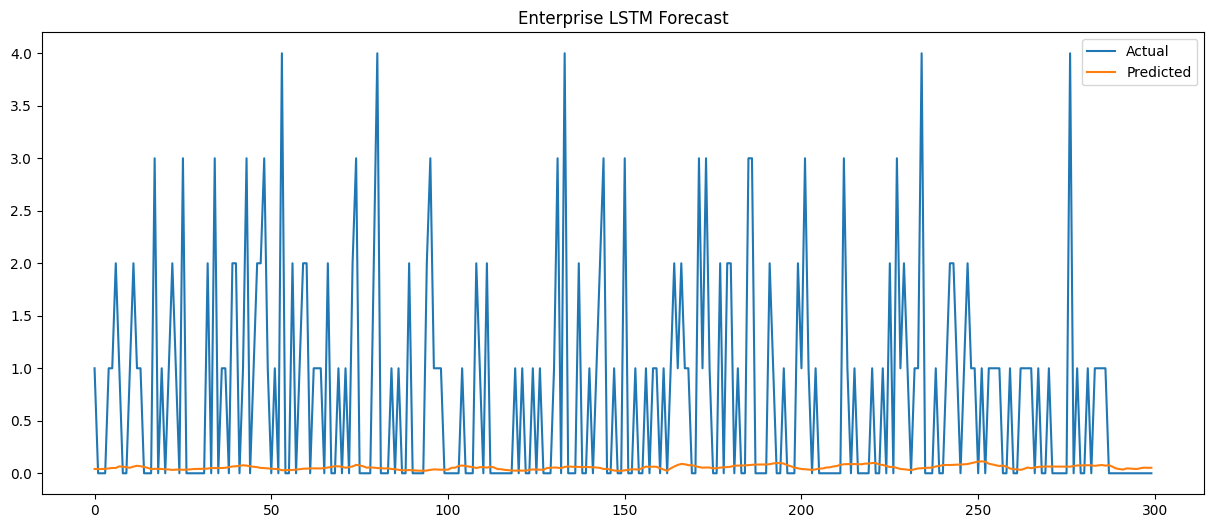

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    y_true[:300],
    label="Actual"
)

plt.plot(
    y_pred[:300],
    label="Predicted"
)

plt.title("Enterprise LSTM Forecast")

plt.legend()

plt.show()

**Save Model**

In [ ]:
model.save(
    MODEL_PATH + "Enterprise_LSTM.keras"
)

print("Enterprise LSTM Saved Successfully")

Enterprise LSTM Saved Successfully


**Save Metrics**

In [ ]:
import pandas as pd

metrics_df = pd.DataFrame({

    "Model": ["Enterprise LSTM"],

    "MAE": [mae],

    "RMSE": [rmse],

    "MAPE": [mape],

    "R2": [r2]

})

metrics_df.to_csv(
    RESULTS_PATH + "lstm_metrics.csv",
    index=False
)

print(metrics_df)
print("✅ Metrics saved successfully!")

             Model       MAE      RMSE        MAPE        R2
0  Enterprise LSTM  2.059405  4.293195  130.903946  0.580168
✅ Metrics saved successfully!
